# Ajuste da constante T = c * S/f + k
Este notebook carrega as 9 medições calibrar_cn_1..9.csv, calcula média e desvio padrão de training_time para cada frequência de cada estação, e ajusta por mínimos quadrados a relação entre o tempo médio e S/f para estimar as constantes c e k.

In [109]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint

plt.rcParams.update({'figure.figsize': (8, 5), 'font.size': 12})

In [110]:
# Localiza a raiz do projeto e o arquivo de constantes das estações

def find_repo_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'calibrar_cn').exists() and (candidate / 'Analise').exists():
            return candidate
    return start

repo_root = find_repo_root()
analysis_dir = repo_root / 'Analise' / 'calibrar_cn_11'
sta_const_path = repo_root / 'Analise' / 'sta_const.json'

data_dir = analysis_dir / 'data'

if not sta_const_path.exists():
    raise FileNotFoundError(f'sta_const.json não encontrado em {sta_const_path}')

if not data_dir.exists():
    raise FileNotFoundError(f'Pasta de dados não encontrada em {data_dir}')

with open(sta_const_path, 'r') as f:
    instancia = json.load(f)

print('repo_root =', repo_root)
print('analysis_dir =', analysis_dir)
print('data_dir =', data_dir)
pprint({k: instancia.get(k) for k in ('N', 'f_min', 'f_max')})

repo_root = /home/nilo/Documents/dissertacao_code_calibrar_constantes
analysis_dir = /home/nilo/Documents/dissertacao_code_calibrar_constantes/Analise/calibrar_cn_11
data_dir = /home/nilo/Documents/dissertacao_code_calibrar_constantes/Analise/calibrar_cn_11/data
{'N': 11,
 'f_max': [2.0, 1.8, 3.6, 2.3, 3.7, 2.4, 2.7, 2.0, 2.9, 3.6, 3.9],
 'f_min': [1.4, 1.5, 1.5, 1.4, 1.4, 1.5, 1.4, 1.6, 2.6, 2.6, 2.6]}


In [111]:
# Carrega os 9 CSVs em uma lista
csv_paths = sorted(data_dir.glob('calibrar_cn_[1-9].csv'))
if len(csv_paths) != 9:
    raise FileNotFoundError(f'Foram encontrados {len(csv_paths)} CSVs, esperados 9 em {data_dir}')

dfs = [pd.read_csv(p, sep=',', index_col=0) for p in csv_paths]
print('Arquivos carregados:')
for p in csv_paths:
    print(' -', p.name)

print('Número de medições:', len(dfs))

Arquivos carregados:
 - calibrar_cn_1.csv
 - calibrar_cn_2.csv
 - calibrar_cn_3.csv
 - calibrar_cn_4.csv
 - calibrar_cn_5.csv
 - calibrar_cn_6.csv
 - calibrar_cn_7.csv
 - calibrar_cn_8.csv
 - calibrar_cn_9.csv
Número de medições: 9


In [112]:
# Identifica as colunas de tempo e de tamanho do modelo para cada estação
all_time_cols = [c for c in dfs[0].columns if c.startswith('training_time_sta')]
all_datasz_cols = [c for c in dfs[0].columns if c.startswith('sta') and c.endswith('_datasz')]

station_ids = [int(c.split('training_time_sta')[1]) for c in all_time_cols]
print('Estações encontradas:', station_ids)
print('Exemplo de colunas de treino:', all_time_cols[:5])
print('Exemplo de colunas de tamanho:', all_datasz_cols[:5])

Estações encontradas: [8, 4, 10, 1, 0, 9, 7, 6, 3, 5, 2]
Exemplo de colunas de treino: ['training_time_sta8', 'training_time_sta4', 'training_time_sta10', 'training_time_sta1', 'training_time_sta0']
Exemplo de colunas de tamanho: ['sta0_datasz', 'sta1_datasz', 'sta3_datasz', 'sta2_datasz', 'sta4_datasz']


In [113]:
# Gera as frequências para cada estação a partir de f_min e f_max
num_rows = len(dfs[0])
num_stations = len(station_ids)

f_min = instancia.get('f_min', [])[:num_stations]
f_max = instancia.get('f_max', [])[:num_stations]

if len(f_min) != num_stations or len(f_max) != num_stations:
    raise ValueError(f'Inconsistência entre o número de estações ({num_stations}) e os vetores f_min/f_max ({len(f_min)}/{len(f_max)})')

freqs = {
    sid: np.linspace(f_min[i]*1e9, f_max[i]*1e9, num_rows)
    for i, sid in enumerate(station_ids)
}

freqs

{8: array([1.40000000e+09, 1.41538462e+09, 1.43076923e+09, 1.44615385e+09,
        1.46153846e+09, 1.47692308e+09, 1.49230769e+09, 1.50769231e+09,
        1.52307692e+09, 1.53846154e+09, 1.55384615e+09, 1.56923077e+09,
        1.58461538e+09, 1.60000000e+09, 1.61538462e+09, 1.63076923e+09,
        1.64615385e+09, 1.66153846e+09, 1.67692308e+09, 1.69230769e+09,
        1.70769231e+09, 1.72307692e+09, 1.73846154e+09, 1.75384615e+09,
        1.76923077e+09, 1.78461538e+09, 1.80000000e+09, 1.81538462e+09,
        1.83076923e+09, 1.84615385e+09, 1.86153846e+09, 1.87692308e+09,
        1.89230769e+09, 1.90769231e+09, 1.92307692e+09, 1.93846154e+09,
        1.95384615e+09, 1.96923077e+09, 1.98461538e+09, 2.00000000e+09]),
 4: array([1.50000000e+09, 1.50769231e+09, 1.51538462e+09, 1.52307692e+09,
        1.53076923e+09, 1.53846154e+09, 1.54615385e+09, 1.55384615e+09,
        1.56153846e+09, 1.56923077e+09, 1.57692308e+09, 1.58461538e+09,
        1.59230769e+09, 1.60000000e+09, 1.60769231e+09, 

In [114]:
# Calcula média e desvio padrão do training_time para cada frequência e estação
summary_by_station = {}

for sid in station_ids:
    time_col = f'training_time_sta{sid}'
    datasz_col = f'sta{sid}_datasz'

    stacked = pd.concat([df[time_col].reset_index(drop=True) for df in dfs], axis=1)
    stacked.columns = [f'meas_{i + 1}' for i in range(len(dfs))]

    mean_series = stacked.mean(axis=1)
    std_series = stacked.std(axis=1, ddof=1)

    raw_model_sz = dfs[0][datasz_col].dropna().reset_index(drop=True)
    if raw_model_sz.empty:
        model_sz_val = np.nan
    else:
        model_sz_val = float(raw_model_sz.iloc[0])
    model_sz_series = pd.Series([model_sz_val] * num_rows, dtype=float)
    freq_series = pd.Series(freqs[sid], name='freq')

    summary_by_station[sid] = pd.DataFrame({
        'freq': freq_series,
        'model_sz': model_sz_series,
        'mean_training_time': mean_series,
        'std_training_time': std_series,
        'x_model_sz_over_freq': model_sz_series / freq_series
    })

summary_by_station[station_ids[0]].head()

,freq,model_sz,mean_training_time,std_training_time,x_model_sz_over_freq
0,1.400000e+09,352361088.0,5.720180,0.030134,0.251686
1,1.415385e+09,352361088.0,5.247776,0.028537,0.248951
2,1.430769e+09,352361088.0,5.235964,0.033647,0.246274
3,1.446154e+09,352361088.0,4.919543,0.020031,0.243654
4,1.461538e+09,352361088.0,4.942194,0.033204,0.241089


In [115]:
# Ajuste por mínimos quadrados: mean_training_time = c * (model_sz / freq) + k
from numpy.linalg import lstsq

fit_rows = []
for sid, stats in summary_by_station.items():
    x = stats['x_model_sz_over_freq'].to_numpy()
    y = stats['mean_training_time'].to_numpy()
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0)

    if mask.sum() < 2:
        continue

    A = np.vstack([x[mask], np.ones_like(x[mask])]).T
    yv = y[mask]
    coeffs, *_ = lstsq(A, yv, rcond=None)
    c, k = float(coeffs[0]), float(coeffs[1])
    y_fit = A @ coeffs

    ss_res = np.sum((yv - y_fit) ** 2)
    ss_tot = np.sum((yv - yv.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

    fit_rows.append({'station_id': sid, 'c': c, 'k': k, 'R2': r2, 'n_points': int(mask.sum())})
    stats['y_fit'] = np.nan
    stats.loc[mask, 'y_fit'] = y_fit

fit_summary = pd.DataFrame(fit_rows).sort_values('station_id')
fit_summary

,station_id,c,k,R2,n_points
4,0,19.110803,5.587737,0.948829,40
3,1,24.552482,1.715871,0.906226,40
10,2,71.603179,-10.040927,0.894765,40
8,3,192.379054,-57.279117,0.899283,40
1,4,99.518693,-20.478582,0.934683,40
9,5,80.722452,-11.943584,0.913608,40
7,6,67.163232,-22.112413,0.973047,40
6,7,17.894205,7.121627,0.951996,40
0,8,13.079619,1.895317,0.819940,40
5,9,13.156228,5.860910,0.762287,40


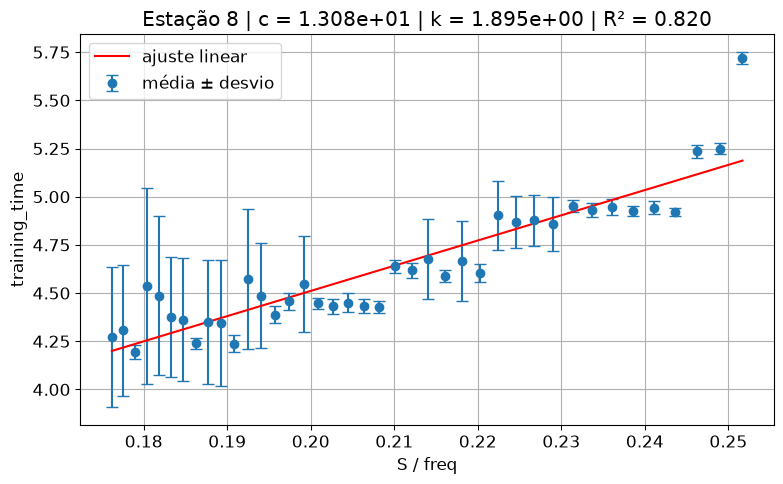

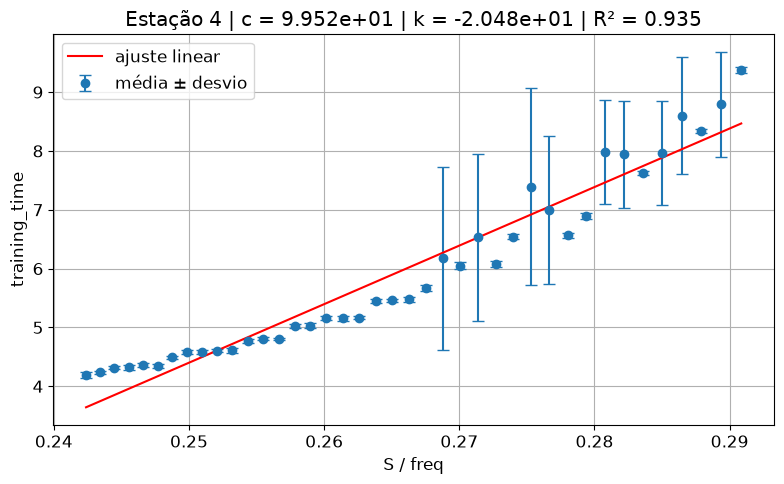

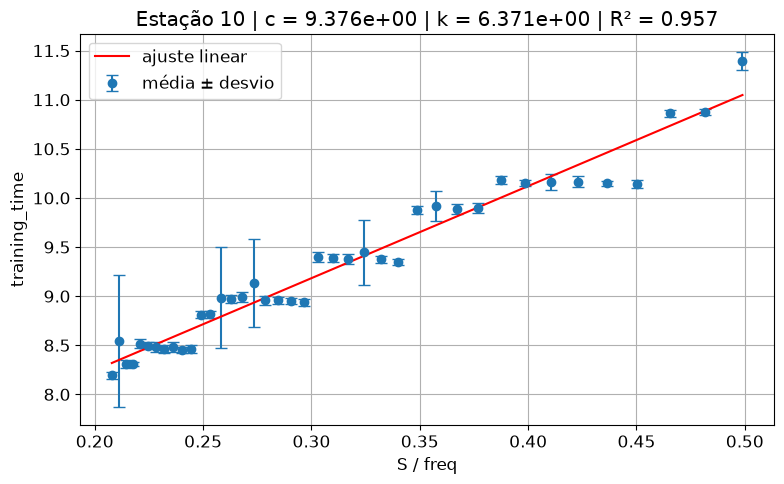

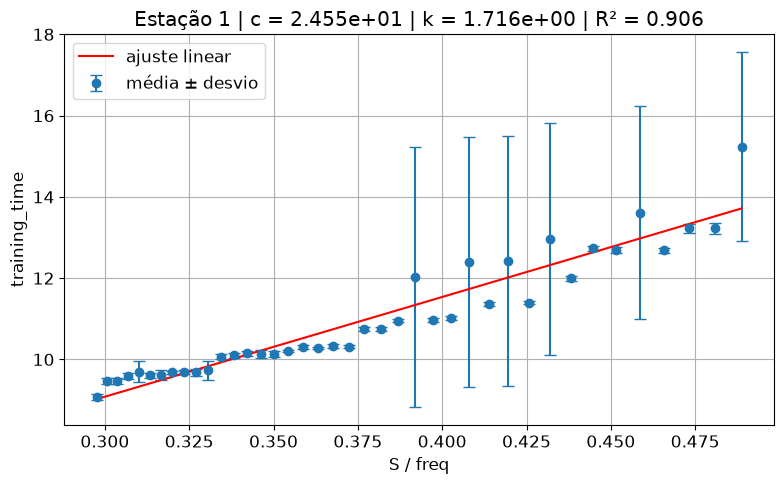

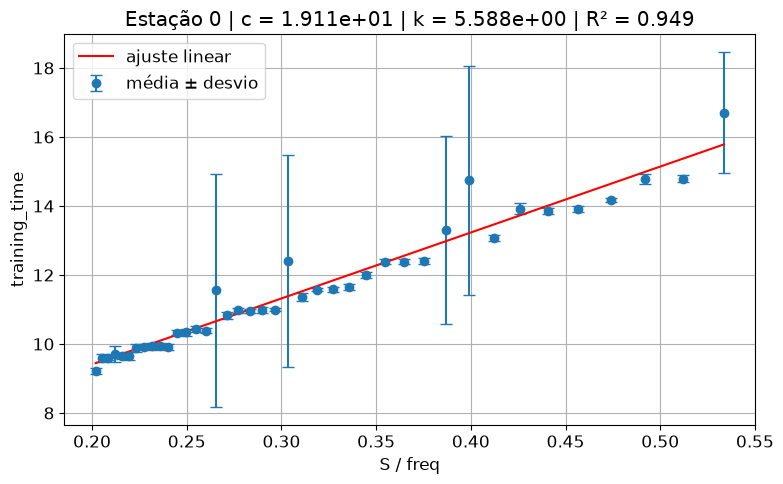

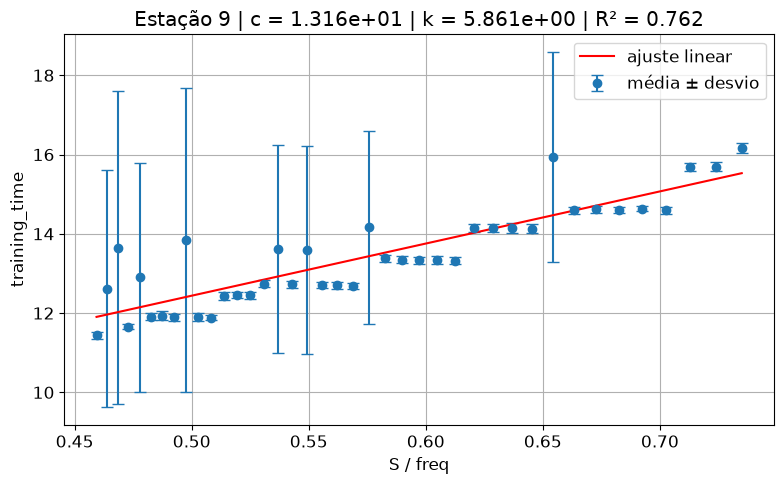

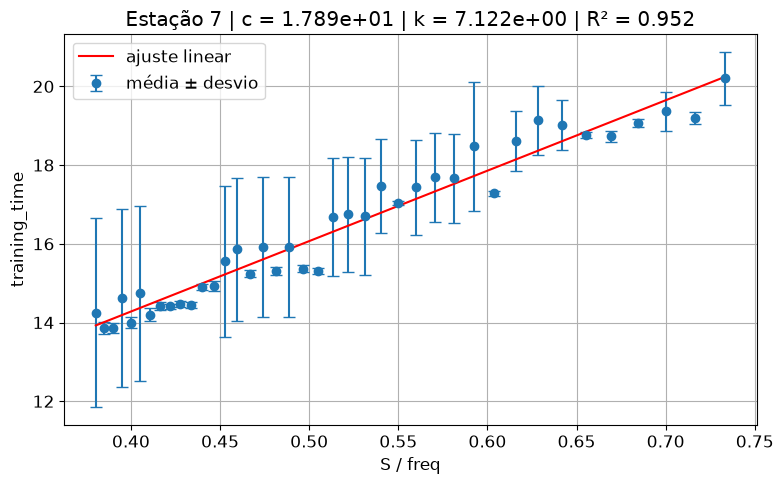

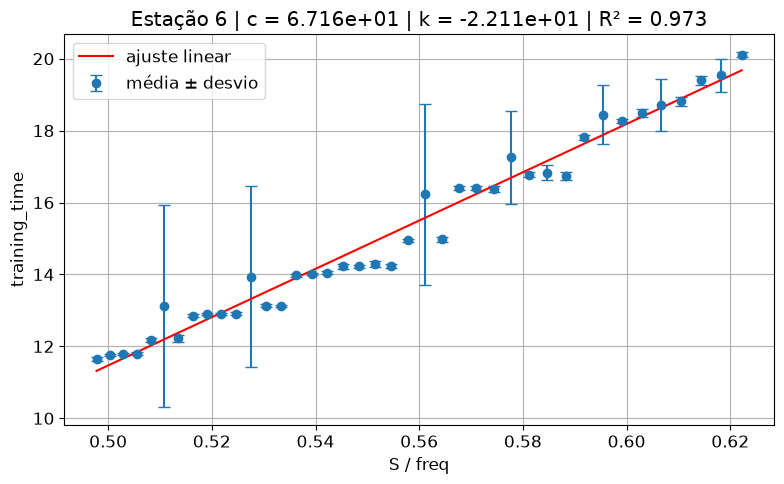

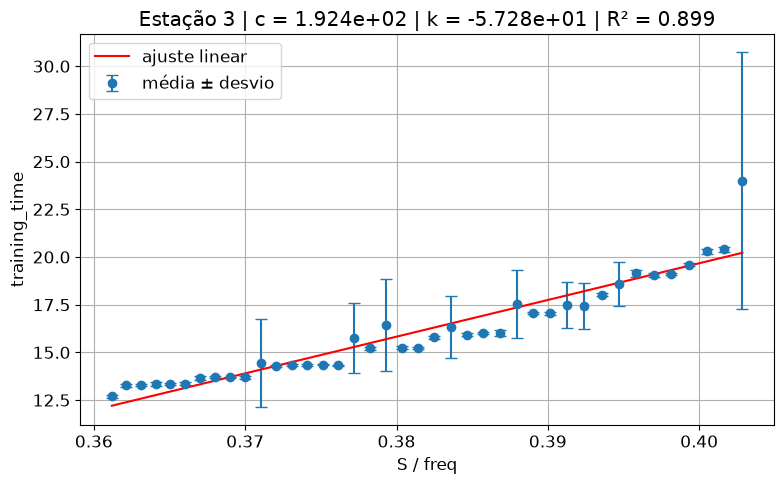

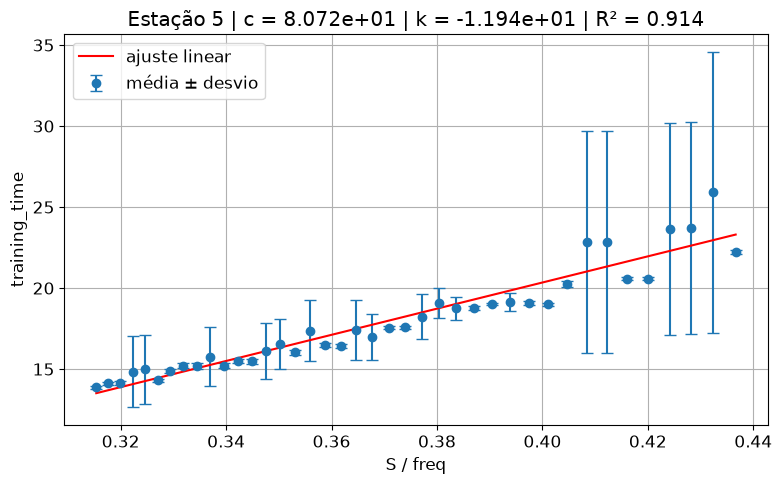

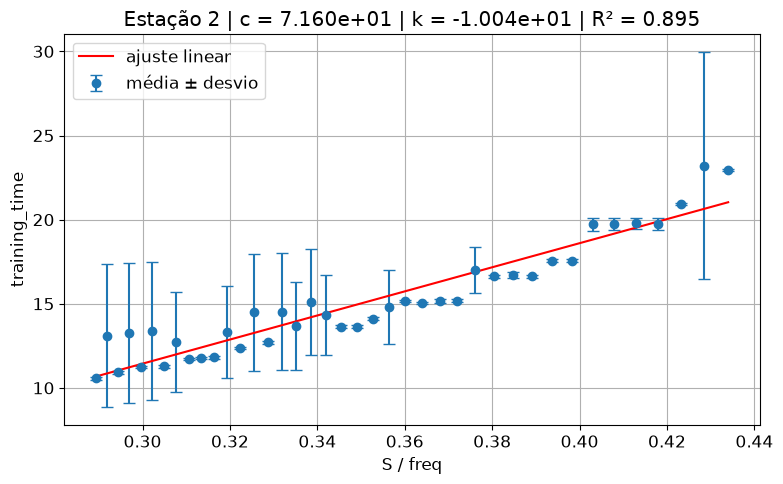

In [116]:
# Plota os resultados para cada estação
for sid, stats in summary_by_station.items():
    plt.figure()
    plt.errorbar(
        stats['x_model_sz_over_freq'],
        stats['mean_training_time'],
        yerr=stats['std_training_time'],
        fmt='o',
        capsize=4,
        label='média ± desvio'
    )
    plt.plot(
        stats['x_model_sz_over_freq'],
        stats['y_fit'],
        color='red',
        label='ajuste linear'
    )
    station_fit = fit_summary.loc[fit_summary['station_id'] == sid]
    if not station_fit.empty:
        c = station_fit['c'].iloc[0]
        k = station_fit['k'].iloc[0]
        r2 = station_fit['R2'].iloc[0]
        plt.title(f'Estação {sid} | c = {c:.3e} | k = {k:.3e} | R² = {r2:.3f}')
    plt.xlabel('S / freq')
    plt.ylabel('training_time')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [117]:
# Salva os resumos em CSVs na pasta do notebook
summary_all = pd.concat(summary_by_station.values(), keys=summary_by_station.keys(), names=['station_id', 'row'])
summary_all = summary_all.reset_index(level=0)
summary_all.to_csv(analysis_dir / 'training_time_summary.csv', index=False)
fit_summary.to_csv(analysis_dir / 'fit_summary.csv', index=False)

print('Arquivos salvos em', analysis_dir)
print(summary_all.head())
print(fit_summary)

Arquivos salvos em /home/nilo/Documents/dissertacao_code_calibrar_constantes/Analise/calibrar_cn_11
     station_id          freq     model_sz  mean_training_time  \
row                                                              
0             8  1.400000e+09  352361088.0            5.720180   
1             8  1.415385e+09  352361088.0            5.247776   
2             8  1.430769e+09  352361088.0            5.235964   
3             8  1.446154e+09  352361088.0            4.919543   
4             8  1.461538e+09  352361088.0            4.942194   

     std_training_time  x_model_sz_over_freq     y_fit  
row                                                     
0             0.030134              0.251686  5.187281  
1             0.028537              0.248951  5.151499  
2             0.033647              0.246274  5.116486  
3             0.020031              0.243654  5.082218  
4             0.033204              0.241089  5.048672  
    station_id           c          k 